# KITTI Pose 궤적 시각화

KITTI 데이터셋의 카메라 pose 파일을 읽어 차량의 이동 궤적을 시각화합니다.

## 파이프라인
1. 라이브러리 임포트 및 설정
2. 데이터 로드 및 파싱
3. 위치 추출 및 통계 계산
4. 2D / 3D 시각화 함수 정의
5. 속도 프로파일 시각화 함수 정의
6. 메인 실행 및 결과 출력

In [8]:
# ── Step 1. 라이브러리 임포트 및 설정 ────────────────────────────────────────

import argparse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# Jupyter 인라인 출력 설정
%matplotlib inline
plt.style.use("dark_background")

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [9]:
# ── Step 2. 데이터 로드 및 파싱 ──────────────────────────────────────────────

def load_poses(pose_file: Path) -> np.ndarray:
    """
    KITTI pose txt 파일을 읽어 (N, 4, 4) 변환 행렬 배열로 반환합니다.
    각 줄: 12개 숫자 → 3×4 행렬 → 4×4 동차 변환 행렬로 확장
    """
    poses = []
    with open(pose_file, "r") as f:
        for line in f:
            vals = list(map(float, line.strip().split()))
            if len(vals) != 12:
                continue
            T = np.eye(4)
            T[:3, :] = np.array(vals).reshape(3, 4)
            poses.append(T)
    return np.array(poses)  # (N, 4, 4)


# 파일 경로 설정 및 로드 실행data_odometry_poses
POSE_FILE = Path("D:/user/Downloads/data_odometry_poses/dataset/poses/09.txt")  # ← 경로 수정
MODE      = "both"   # "2d" | "3d" | "both"
OUT_DIR   = None     # 저장 경로 (None이면 화면 출력)

poses = load_poses(POSE_FILE)
print(f"로드된 pose 수: {len(poses)}")
print(f"배열 shape: {poses.shape}")
print(f"\n첫 번째 변환 행렬:\n{poses[0]}")

로드된 pose 수: 1591
배열 shape: (1591, 4, 4)

첫 번째 변환 행렬:
[[1.000000e+00 1.197625e-11 1.704638e-10 5.551115e-17]
 [1.197625e-11 1.000000e+00 3.562503e-10 0.000000e+00]
 [1.704638e-10 3.562503e-10 1.000000e+00 2.220446e-16]
 [0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00]]


In [10]:
# ── Step 3. 위치 추출 및 통계 계산 ───────────────────────────────────────────

def extract_positions(poses: np.ndarray) -> np.ndarray:
    """변환 행렬에서 카메라 위치 (tx, ty, tz) 추출 → (N, 3)"""
    return poses[:, :3, 3]


def compute_forward_vectors(poses: np.ndarray) -> np.ndarray:
    """
    각 프레임에서 카메라가 바라보는 방향 벡터(Z축)를 추출합니다.
    KITTI 카메라 좌표계에서는 Z축이 앞 방향입니다.
    """
    return poses[:, :3, 2]


def compute_statistics(positions: np.ndarray, poses: np.ndarray) -> dict:
    """이동 궤적 통계 계산"""
    deltas         = np.diff(positions, axis=0)           # (N-1, 3)
    frame_distances = np.linalg.norm(deltas, axis=1)      # (N-1,)

    fps    = 10.0                                          # KITTI ≈ 10Hz
    speeds = frame_distances * fps                         # m/s

    yaw_angles  = np.degrees(np.arctan2(deltas[:, 0], deltas[:, 2]))
    total_dist  = frame_distances.sum()
    straight_dist = np.linalg.norm(positions[-1] - positions[0])

    return {
        "frame_distances": frame_distances,
        "speeds":          speeds,
        "yaw_angles":      yaw_angles,
        "total_dist":      total_dist,
        "straight_dist":   straight_dist,
        "avg_speed":       speeds.mean(),
        "max_speed":       speeds.max(),
    }


def print_summary(positions: np.ndarray, stats: dict, seq_name: str):
    """이동 방향·속도 통계 출력"""
    n = len(positions)
    print("=" * 55)
    print(f"  KITTI Pose 분석  ─  Sequence {seq_name}")
    print("=" * 55)
    print(f"  총 프레임 수       : {n}")
    print(f"  총 이동 거리       : {stats['total_dist']:.2f} m")
    print(f"  직선 변위 (시작→끝): {stats['straight_dist']:.2f} m")
    print(f"  평균 속도          : {stats['avg_speed']:.2f} m/s  ({stats['avg_speed']*3.6:.1f} km/h)")
    print(f"  최고 속도          : {stats['max_speed']:.2f} m/s  ({stats['max_speed']*3.6:.1f} km/h)")
    print()
    print("  시작 위치 (x, y, z):", np.round(positions[0], 3))
    print("  종료 위치 (x, y, z):", np.round(positions[-1], 3))
    print()
    yaw = stats["yaw_angles"]
    print("  이동 방향 분포 (yaw 각도 기준):")
    buckets = [
        ("직진 (±15°)",        (-15,  15)),
        ("우회전 (15~90°)",    ( 15,  90)),
        ("좌회전 (-90~-15°)",  (-90, -15)),
    ]
    for label, (lo, hi) in buckets:
        count = np.sum((yaw >= lo) & (yaw < hi))
        pct   = count / len(yaw) * 100
        print(f"    {label:22s}: {count:4d} 프레임  ({pct:.1f}%)")
    print("=" * 55)


# ── 실행 ──
seq_name  = POSE_FILE.stem
T0_inv    = np.linalg.inv(poses[0])
poses_rel = np.array([T0_inv @ p for p in poses])   # 0번 프레임 기준 상대 좌표

positions = extract_positions(poses_rel)
stats     = compute_statistics(positions, poses_rel)

print_summary(positions, stats, seq_name)

  KITTI Pose 분석  ─  Sequence 09
  총 프레임 수       : 1591
  총 이동 거리       : 1705.05 m
  직선 변위 (시작→끝): 9.27 m
  평균 속도          : 10.72 m/s  (38.6 km/h)
  최고 속도          : 15.45 m/s  (55.6 km/h)

  시작 위치 (x, y, z): [0. 0. 0.]
  종료 위치 (x, y, z): [-3.007  3.046  8.223]

  이동 방향 분포 (yaw 각도 기준):
    직진 (±15°)             :  173 프레임  (10.9%)
    우회전 (15~90°)          :  395 프레임  (24.8%)
    좌회전 (-90~-15°)        :  309 프레임  (19.4%)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60: UserWarning: Glyph 50526 (\N{HANGUL SYLLABLE AP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60: UserWarning: Glyph 46244 (\N{HANGUL SYLLABLE DWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\449406012.py:60:

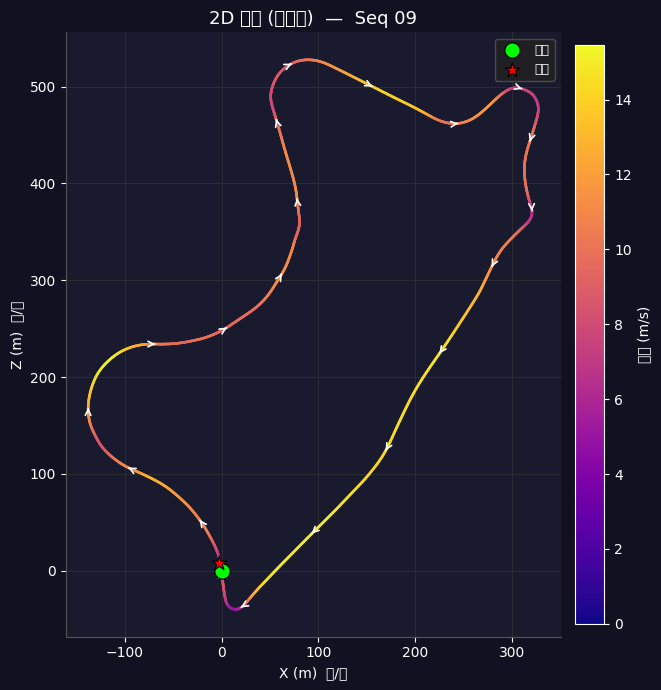

In [11]:
# ── Step 4. 2D 궤적 시각화 ───────────────────────────────────────────────────

def plot_2d(positions: np.ndarray, stats: dict, seq_name: str, ax: plt.Axes):
    """
    XZ 평면 기준 2D 궤적 (조감도 시점).
    X = 좌우, Z = 앞뒤 (카메라 좌표계)
    """
    x, z = positions[:, 0], positions[:, 2]
    n    = len(x)

    speeds = np.concatenate([[0], stats["speeds"]])
    norm   = mcolors.Normalize(vmin=speeds.min(), vmax=speeds.max())
    cmap   = plt.cm.plasma

    for i in range(n - 1):
        ax.plot(x[i:i+2], z[i:i+2],
                color=cmap(norm(speeds[i])), linewidth=1.8, alpha=0.85)

    ax.scatter(x[0],  z[0],  s=120, c="lime", zorder=5,
               label="시작", edgecolors="black", linewidths=0.8)
    ax.scatter(x[-1], z[-1], s=120, c="red", marker="*", zorder=5,
               label="종료", edgecolors="black", linewidths=0.8)

    step = max(1, n // 20)
    dx, dz = np.diff(x), np.diff(z)
    for i in range(0, n - 1, step):
        d = np.hypot(dx[i], dz[i])
        if d > 1e-6:
            ax.annotate(
                "", xy=(x[i] + dx[i]*0.5, z[i] + dz[i]*0.5),
                xytext=(x[i], z[i]),
                arrowprops=dict(arrowstyle="->", color="white", lw=1.2),
            )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.04)
    cbar.set_label("속도 (m/s)", color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    ax.set_title(f"2D 궤적 (조감도)  —  Seq {seq_name}", color="white", fontsize=13)
    ax.set_xlabel("X (m)  좌/우", color="white")
    ax.set_ylabel("Z (m)  앞/뒤", color="white")
    ax.tick_params(colors="white")
    for sp in ["bottom", "left"]:
        ax.spines[sp].set_color("#555")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.set_facecolor("#1a1a2e")
    ax.legend(facecolor="#222", labelcolor="white", edgecolor="#555", fontsize=9)
    ax.set_aspect("equal")
    ax.grid(True, color="#333", linewidth=0.5)


# ── 단독 실행 (확인용) ──
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#111122")
plot_2d(positions, stats, seq_name, ax)
plt.tight_layout()
plt.show()

In [12]:
# ── Step 5. 3D 궤적 및 속도 프로파일 시각화 ──────────────────────────────────

def plot_3d(positions: np.ndarray, stats: dict, seq_name: str, ax):
    """3D 궤적 시각화 (X, Y, Z 모두 표현)"""
    x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
    n       = len(x)

    speeds = np.concatenate([[0], stats["speeds"]])
    norm   = mcolors.Normalize(vmin=speeds.min(), vmax=speeds.max())
    cmap   = plt.cm.plasma

    for i in range(n - 1):
        color = cmap(norm(speeds[i]))
        ax.plot(x[i:i+2], z[i:i+2], y[i:i+2],
                color=color, linewidth=1.5, alpha=0.85)

    ax.scatter(x[0],  z[0],  y[0],  s=100, c="lime", zorder=5, label="시작")
    ax.scatter(x[-1], z[-1], y[-1], s=100, c="red",  marker="*", zorder=5, label="종료")

    ax.set_title(f"3D 궤적  —  Seq {seq_name}", color="white", fontsize=12)
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Z (m)")
    ax.set_zlabel("Y (m)  ↑ 높이")
    ax.set_facecolor("#1a1a2e")
    ax.legend(fontsize=9)
    ax.tick_params(colors="white")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False


def plot_speed_profile(stats: dict, seq_name: str, ax: plt.Axes):
    """프레임별 속도 프로파일"""
    frames = np.arange(len(stats["speeds"]))
    ax.fill_between(frames, stats["speeds"], alpha=0.4, color="#7c6af7")
    ax.plot(frames, stats["speeds"], color="#a89fff", linewidth=1.2)
    ax.axhline(stats["avg_speed"], color="#ffcc44", linestyle="--", linewidth=1.2,
               label=f"평균 {stats['avg_speed']:.1f} m/s")

    ax.set_title("속도 프로파일", color="white", fontsize=12)
    ax.set_xlabel("프레임", color="white")
    ax.set_ylabel("속도 (m/s)", color="white")
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["bottom", "left"]:
        ax.spines[sp].set_color("#555")
    ax.legend(facecolor="#222", labelcolor="white", edgecolor="#555")
    ax.grid(True, color="#333", linewidth=0.5)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.py:36: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.py:36: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.py:36: UserWarning: Glyph 50526 (\N{HANGUL SYLLABLE AP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.py:36: UserWarning: Glyph 46244 (\N{HANGUL SYLLABLE DWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.py:36: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_65268\1528487364.

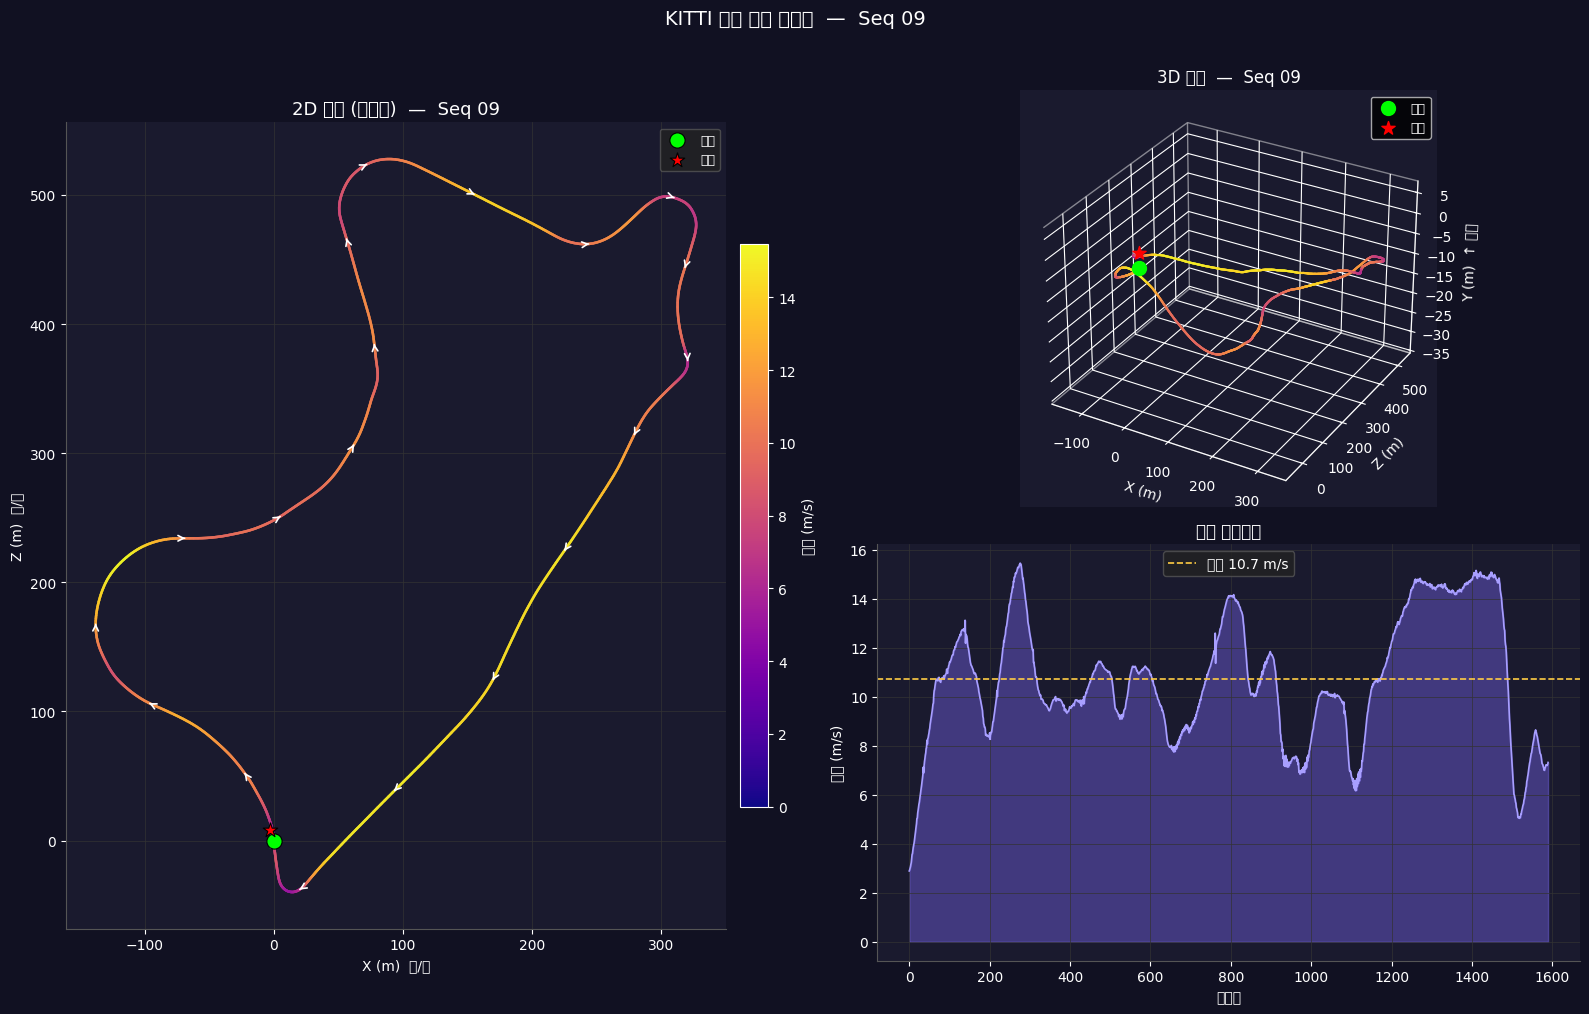

In [13]:
# ── Step 6. 메인 실행 및 최종 결과 출력 ──────────────────────────────────────

def run(poses: np.ndarray, seq_name: str, mode: str, out_dir: Path | None):
    if len(poses) == 0:
        raise ValueError("유효한 pose 데이터가 없습니다.")

    T0_inv    = np.linalg.inv(poses[0])
    poses_rel = np.array([T0_inv @ p for p in poses])
    positions = extract_positions(poses_rel)
    stats     = compute_statistics(positions, poses_rel)

    plt.style.use("dark_background")

    if mode == "both":
        fig    = plt.figure(figsize=(16, 10))
        ax_2d  = fig.add_subplot(2, 2, (1, 3))
        ax_3d  = fig.add_subplot(2, 2, 2, projection="3d")
        ax_spd = fig.add_subplot(2, 2, 4)
        plot_2d(positions, stats, seq_name, ax_2d)
        plot_3d(positions, stats, seq_name, ax_3d)
        plot_speed_profile(stats, seq_name, ax_spd)

    elif mode == "3d":
        fig = plt.figure(figsize=(12, 8))
        ax  = fig.add_subplot(1, 1, 1, projection="3d")
        plot_3d(positions, stats, seq_name, ax)

    else:  # "2d"
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        plot_2d(positions, stats, seq_name, axes[0])
        plot_speed_profile(stats, seq_name, axes[1])

    fig.patch.set_facecolor("#111122")
    plt.suptitle(f"KITTI 차량 궤적 시각화  —  Seq {seq_name}",
                 color="white", fontsize=14, y=1.01)
    plt.tight_layout()

    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        save_path = out_dir / f"trajectory_{seq_name}_{mode}.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"저장 완료: {save_path}")
    else:
        plt.show()


# ── 실행 ──
run(poses, seq_name, MODE, OUT_DIR)

## 차량의 이동 방향과 속도
- 왼쪽 그래프는 차량의 2D 이동 궤적이다. 왼쪽 아래 초록점에서 시작해 반시계 방향으로 주행했으며, 출발점과 도착점이 동일함을 확인할 수 있다. 또한 오른쪽 위 3D 그래프를 확인했을 때 평탄한 지형이 아닌 경사 있는 지형에서 주행했음을 확인할 수 있다.

- 오른쪽 아래 속도 그래프를 확인햇을 때 평균 속력은 10.7 m/s이며, 주행 중 속도가 자주 변했음을 확인할 수 있다. 오른쪽 위 컬러맵까지 함께 확인한 결과로 보아 직선 지형에서 속도가 빠르고, 경사면에서 느린 속도로 주행하였음을 확인할 수 있다.